# **Predição de Links em Grafos: Fundamentos e Medidas Clássicas**

Francisco A. Rodrigues, francisco@icmc.usp.br.<br>
Universidade de São Paulo, São Carlos, Brasil.<br>
https://sites.icmc.usp.br/francisco <br>
<hr>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

# Semente fixa para reprodutibilidade
SEED = 42
np.random.seed(SEED)

plt.rcParams['figure.figsize'] = (6, 5)
plt.rcParams['font.size'] = 11

print('NetworkX versão:', nx.__version__)

NetworkX versão: 3.6.1


## 1. Introdução

### O problema de predição de links

Considere um grafo

$$
G = (V, E),
$$

onde $V$ é o conjunto de vértices e $E$ o conjunto de arestas (links) observados.

O problema de **predição de links** consiste em, para cada par de vértices atualmente **não conectado**,

$$
(i, j) \notin E,
$$

atribuir um **escore**

$$
s(i, j),
$$

de modo que valores maiores de $s(i,j)$ indiquem pares considerados **mais prováveis** de estarem, ou virem a estar, conectados.

Em outras palavras: em vez de responder apenas "existe uma aresta entre $i$ e $j$?" (sim/não), queremos **ranquear** todos os pares não conectados por probabilidade de conexão.

### Aplicações

A predição de links aparece em diversos contextos:

- **Recomendação de amizade** em redes sociais (ex.: "pessoas que você talvez conheça");
- **Previsão de novas colaborações científicas** em redes de coautoria;
- **Previsão de interações entre proteínas** em biologia de sistemas;
- **Recomendação de produtos** (redes bipartidas usuário-produto);
- **Redes de citações**, sugerindo referências relevantes ainda não citadas;
- **Redes de transporte**, sugerindo novas rotas ou conexões;
- **Redes de conhecimento** (*knowledge graphs*), completando fatos ausentes.

### Dois problemas relacionados, mas diferentes

É importante distinguir claramente dois cenários:

- **Missing link prediction** (predição de links ausentes): a rede real já possui essas conexões, mas elas não foram *observadas*, por exemplo, um levantamento de dados incompleto. O objetivo é **recuperar** conexões que já existem, mas estão escondidas dos nossos dados.
- **Future link prediction** (predição de links futuros): a rede evolui no tempo, e queremos prever quais conexões **ainda serão formadas** no futuro.

Matematicamente, as duas tarefas usam praticamente as mesmas ferramentas: a diferença está na interpretação do resultado. Neste notebook, vamos nos concentrar no primeiro caso (**missing link prediction**), pois ele permite estudar os métodos de forma controlada: podemos esconder uma aresta que sabemos que existe e verificar se o método consegue "recuperá-la".

## 2. Intuição estrutural

Antes de qualquer fórmula, vale entender **de onde vem a intuição** por trás dos métodos clássicos de predição de links. Duas ideias centrais aparecem repetidamente na literatura.

### 2.1 Fechamento triádico (*triadic closure*)

A ideia é simples e muito intuitiva:

> "Se Alice conhece Bruno, e Bruno conhece Carlos, então Alice e Carlos possuem maior chance de se conhecerem no futuro (ou de já se conhecerem, mas isso não foi registrado)."

Isso é chamado de **fechamento triádico**: um caminho de comprimento 2 ($i - z - j$) tende a "fechar" um triângulo, formando a aresta direta $i-j$.

Vamos visualizar essa ideia com um grafo mínimo.

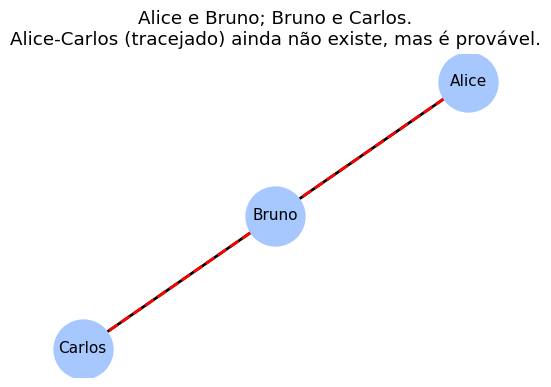

In [ ]:
# Um exemplo mínimo de fechamento triadico
G_exemplo = nx.Graph()
G_exemplo.add_edges_from([('Alice', 'Bruno'), ('Bruno', 'Carlos')])

pos = nx.spring_layout(G_exemplo, seed=SEED)

fig, ax = plt.subplots(figsize=(5, 4))
nx.draw_networkx_nodes(G_exemplo, pos, node_color='#a6c8ff', node_size=1800, ax=ax)
nx.draw_networkx_edges(G_exemplo, pos, width=2, ax=ax)
nx.draw_networkx_labels(G_exemplo, pos, font_size=11, ax=ax)

# Desenhamos a aresta hipotetica Alice-Carlos como tracejada, ainda inexistente
nx.draw_networkx_edges(
    G_exemplo, pos, edgelist=[('Alice', 'Carlos')],
    style='dashed', edge_color='red', width=2, ax=ax
)

ax.set_title('Alice e Bruno; Bruno e Carlos.\nAlice-Carlos (tracejado) ainda não existe, mas é provável.')
ax.axis('off')
plt.tight_layout()
plt.show()

Note que Alice e Carlos **não estão diretamente conectados**, mas compartilham um vizinho em comum: Bruno. Essa é exatamente a informação que a maioria das medidas clássicas de predição de links vai explorar: **quantos (e quais) vizinhos dois vértices têm em comum**.

Vamos formalizar essa noção de "vizinhos em comum" mais adiante (Seção 4). Antes, vale destacar uma segunda ideia importante.

### 2.2 Homofilia

**Homofilia** é a tendência de vértices semelhantes se conectarem entre si.

É importante diferenciar duas noções de similaridade:

- **Similaridade estrutural**: dois vértices são "parecidos" pela forma como estão posicionados na rede (compartilham vizinhos, têm graus parecidos, ocupam papéis semelhantes na topologia).
- **Similaridade baseada em atributos**: dois vértices são "parecidos" por características externas ao grafo (ex.: mesma idade, mesmo interesse, mesma localização, mesmo departamento).

**Neste primeiro notebook, vamos utilizar apenas informação estrutural do grafo**, ou seja, nenhum atributo externo dos vértices. Isso significa que todos os métodos que veremos (Common Neighbors, Jaccard, Adamic-Adar, Resource Allocation e Preferential Attachment) são medidas de **similaridade estrutural**.

## 3. Exemplo

Vamos construir, à mão, um grafo pequeno (10 vértices) especialmente desenhado para ilustrar diferentes situações estruturais:

- pares sem nenhum vizinho em comum;
- pares com um vizinho em comum;
- pares com vários vizinhos em comum;
- pares cujos vizinhos comuns têm graus bem diferentes (útil mais adiante, para Adamic-Adar);
- vértices com graus bastante distintos (um "hub" e vários vértices de grau baixo).

Vamos numerar os vértices de `0` a `9`.

In [ ]:
G = nx.Graph()

arestas = [
    (0, 1), (0, 2), (0, 3), (0, 4), (0, 5),   # 0 é um hub, conectado a vários vértices
    (1, 2), (1, 3),
    (3, 4),
    (5, 6), (5, 7), (5, 8),
    (6, 7),
    (2, 6),
    (4, 8),
    (8, 9),
]

G.add_edges_from(arestas)

print(f'Número de vértices: {G.number_of_nodes()}')
print(f'Número de arestas:  {G.number_of_edges()}')

Número de vértices: 10
Número de arestas:  15


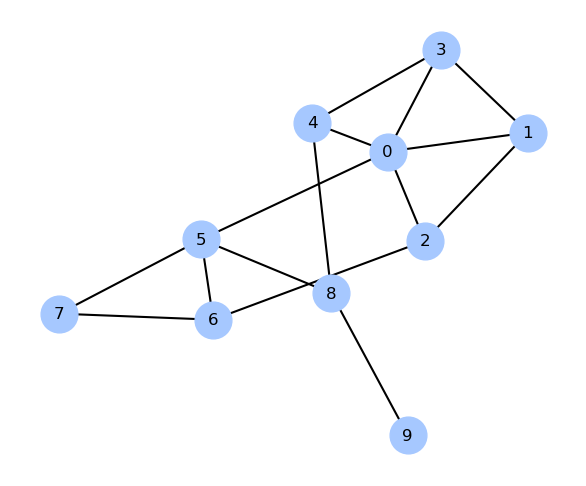

In [ ]:
pos = nx.spring_layout(G, seed=SEED)

fig, ax = plt.subplots(figsize=(6, 5))
nx.draw_networkx_nodes(G, pos, node_color='#a6c8ff', node_size=700, ax=ax)
nx.draw_networkx_edges(G, pos, width=1.5, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=12, ax=ax)
ax.axis('off')
plt.tight_layout()
plt.show()

Vamos agora examinar os graus de cada vértice.

In [ ]:
graus = dict(G.degree())

df_graus = pd.DataFrame({
    'vertice': list(graus.keys()),
    'grau': list(graus.values())
}).sort_values('grau', ascending=False).reset_index(drop=True)

df_graus

,vertice,grau
0,0,5
1,5,4
2,1,3
3,2,3
4,3,3
5,4,3
6,6,3
7,8,3
8,7,2
9,9,1


Note que o vértice `0` tem grau 5 (um pequeno "hub"), enquanto o vértice `9` tem grau 1 (uma "folha" da rede). Essa diferença de graus será importante para entender por que alguns métodos (como Preferential Attachment) se comportam de forma tão diferente dos métodos baseados em vizinhos comuns.

### Pares não conectados

Os pares de vértices **sem aresta entre eles** são exatamente os candidatos que um método de predição de links deve avaliar e ranquear.

In [ ]:
pares_nao_conectados = list(nx.non_edges(G))

print(f'Número de pares não conectados: {len(pares_nao_conectados)}')
print()
print('Alguns exemplos:')
for par in pares_nao_conectados[:10]:
    print(par)

Número de pares não conectados: 30

Alguns exemplos:
(0, 8)
(0, 9)
(0, 6)
(0, 7)
(1, 4)
(1, 5)
(1, 6)
(1, 7)
(1, 8)
(1, 9)


Esses `30` pares (número de pares totais menos as `14` arestas existentes) são os candidatos à formação de novos links. É sobre eles que vamos calcular os escores das próximas seções.

Ainda não vamos esconder nenhuma aresta artificialmente, isso será feito só na Seção 11, quando falarmos sobre avaliação. Por enquanto, trabalhamos apenas com os pares que **naturalmente** não têm conexão no grafo.

## 4. Common Neighbors

A primeira e mais simples medida de predição de links formaliza diretamente a ideia de fechamento triádico da Seção 2.1: contar quantos vizinhos dois vértices têm em comum.

$$
CN(i, j) = |\Gamma(i) \cap \Gamma(j)|,
$$

onde $\Gamma(i)$ denota o conjunto de vizinhos do vértice $i$.

**Interpretação:** quanto mais vizinhos em comum dois vértices possuem, maior tende a ser a chance de formação de uma conexão entre eles. Cada vizinho comum é, intuitivamente, uma "oportunidade" de apresentação social (ou, em outros domínios, uma evidência de proximidade funcional).

Vamos calcular $CN$ para um par específico, passo a passo, antes de escrever qualquer função.

In [ ]:
i, j = 0, 8

vizinhos_i = set(G.neighbors(i))
vizinhos_j = set(G.neighbors(j))

print(f'Vizinhos de {i}: {vizinhos_i}')
print(f'Vizinhos de {j}: {vizinhos_j}')

vizinhos_comuns = vizinhos_i.intersection(vizinhos_j)
print(f'Vizinhos comuns entre {i} e {j}: {vizinhos_comuns}')
print(f'CN({i}, {j}) = {len(vizinhos_comuns)}')

Vizinhos de 0: {1, 2, 3, 4, 5}
Vizinhos de 8: {9, 4, 5}
Vizinhos comuns entre 0 e 8: {4, 5}
CN(0, 8) = 2


Agora que entendemos o cálculo passo a passo, vamos encapsular essa lógica em uma função reutilizável.

In [ ]:
def common_neighbors_score(G, u, v):
    '''Retorna o número de vizinhos em comum entre u e v.'''
    vizinhos_u = set(G.neighbors(u))
    vizinhos_v = set(G.neighbors(v))
    return len(vizinhos_u.intersection(vizinhos_v))

# Testando a função no mesmo par de antes
print(common_neighbors_score(G, 0, 8))

2


Vamos agora calcular o índice para **todos** os pares não conectados do grafo.

In [ ]:
resultados_cn = []

for u, v in pares_nao_conectados:
    cn = common_neighbors_score(G, u, v)
    resultados_cn.append({'u': u, 'v': v, 'common_neighbors': cn})

df_cn = pd.DataFrame(resultados_cn)
df_cn = df_cn.sort_values('common_neighbors', ascending=False).reset_index(drop=True)

df_cn.head(10)

,u,v,common_neighbors
0,0,8,2
1,1,4,2
2,4,5,2
3,2,5,2
4,2,3,2
5,0,6,2
6,1,5,1
7,1,6,1
8,7,8,1
9,6,8,1


### Discussão

Os pares no topo do ranking (maior `common_neighbors`) são os que o método **recomendaria** como novas conexões mais prováveis.

O método apresenta uma limitação. Todos os pares com `common_neighbors = 0` recebem exatamente o mesmo escore. Para resolver isso, vamos consider o Coeficiente de Jaccard.

## 5. Coeficiente de Jaccard

O número absoluto de vizinhos em comum não leva em conta o **tamanho total** da vizinhança de cada vértice. Considere dois pares que tenham o mesmo número de vizinhos comuns, mas graus bem diferentes:

In [ ]:
for u, v in [(0, 6), (1, 4)]:
    viz_u = set(G.neighbors(u))
    viz_v = set(G.neighbors(v))
    comuns = viz_u & viz_v
    uniao = viz_u | viz_v
    print(f'Par ({u}, {v}): CN = {len(comuns)}, grau({u}) = {len(viz_u)}, grau({v}) = {len(viz_v)}, |uniao| = {len(uniao)}')

Par (0, 6): CN = 2, grau(0) = 5, grau(6) = 3, |uniao| = 6
Par (1, 4): CN = 2, grau(1) = 3, grau(4) = 3, |uniao| = 4


Ambos os pares têm o mesmo `Common Neighbors`, mas no par `(0, 6)` os vértices têm graus mais altos. Então, proporcionalmente, o número de vizinhos compartilhados é **menos significativo** do que no par `(1, 4)`, onde os vértices têm menos vizinhos ao todo.

### O índice de Jaccard

Para corrigir esse problema, normalizamos pelo tamanho da **união** das vizinhanças:

$$
J(i, j) = \frac{|\Gamma(i) \cap \Gamma(j)|}{|\Gamma(i) \cup \Gamma(j)|}.
$$

**Interpretação:** o Jaccard mede a *proporção* de vizinhos compartilhados em relação ao total de vizinhos distintos das duas partes, um valor entre 0 (nenhum vizinho em comum) e 1 (vizinhanças idênticas).

### Cálculo manual

In [ ]:
for u, v in [(0, 6), (1, 4)]:
    viz_u = set(G.neighbors(u))
    viz_v = set(G.neighbors(v))
    jaccard = len(viz_u & viz_v) / len(viz_u | viz_v)
    print(f'J({u}, {v}) = {jaccard:.3f}')

J(0, 6) = 0.333
J(1, 4) = 0.500


Como esperado, o par `(1, 4)`, com vizinhanças menores e mais "concentradas", recebe um Jaccard maior, mesmo tendo o mesmo `Common Neighbors` do par `(0, 6)`.

### Usando o NetworkX

O NetworkX já implementa o coeficiente de Jaccard, junto com vários outros índices de predição de links, no módulo `nx.link_prediction`.

In [ ]:
jaccard_resultados = list(nx.jaccard_coefficient(G, pares_nao_conectados))

df_jaccard = pd.DataFrame(jaccard_resultados, columns=['u', 'v', 'jaccard'])
df_jaccard = df_jaccard.sort_values('jaccard', ascending=False).reset_index(drop=True)

df_jaccard.head(10)

,u,v,jaccard
0,2,3,0.500000
1,1,4,0.500000
2,4,5,0.400000
3,2,5,0.400000
4,4,9,0.333333
5,0,8,0.333333
6,0,6,0.333333
7,7,8,0.250000
8,2,7,0.250000
9,5,9,0.250000


### Comparando os rankings

Vamos juntar Common Neighbors e Jaccard em uma única tabela e comparar as posições no ranking.

In [ ]:
df_comp_cn_jac = df_cn.merge(df_jaccard, on=['u', 'v'])
df_comp_cn_jac['rank_cn'] = df_comp_cn_jac['common_neighbors'].rank(ascending=False, method='min')
df_comp_cn_jac['rank_jaccard'] = df_comp_cn_jac['jaccard'].rank(ascending=False, method='min')
df_comp_cn_jac['diferenca_rank'] = (df_comp_cn_jac['rank_cn'] - df_comp_cn_jac['rank_jaccard']).abs()

df_comp_cn_jac.sort_values('diferenca_rank', ascending=False).head(8)

,u,v,common_neighbors,jaccard,rank_cn,rank_jaccard,diferenca_rank
15,3,5,1,0.166667,7.0,15.0,8.0
12,0,7,1,0.166667,7.0,15.0,8.0
6,1,5,1,0.166667,7.0,15.0,8.0
7,1,6,1,0.200000,7.0,11.0,4.0
16,3,8,1,0.200000,7.0,11.0,4.0
11,2,4,1,0.200000,7.0,11.0,4.0
9,6,8,1,0.200000,7.0,11.0,4.0
0,0,8,2,0.333333,1.0,5.0,4.0


### Discussão

Os pares com maior `diferenca_rank` são justamente aqueles em que os dois métodos discordam mais fortemente. Isso costuma acontecer quando o número absoluto de vizinhos comuns é parecido, mas os graus totais dos vértices envolvidos são muito diferentes, exatamente o efeito que Jaccard foi criado para corrigir.

> **Pergunta conceitual:** em uma rede onde todos os vértices têm graus muito parecidos (por exemplo, uma rede quase regular), você esperaria que Common Neighbors e Jaccard produzissem rankings muito diferentes? Por quê?

## 6. Adamic-Adar

Common Neighbors e Jaccard tratam todos os vizinhos comuns igualmente. Mas será que isso faz sentido?

Pense em duas pessoas que têm um "amigo em comum" chamado Z:

- Se Z é uma pessoa com **poucos** amigos (baixo grau), o fato de conhecer as duas é uma coincidência bem específica, uma evidência forte de que as duas estão em círculos sociais próximos.
- Se Z é uma **celebridade** com milhares de seguidores (um hub, alto grau), o fato de as duas seguirem Z diz muito pouco sobre a proximidade real entre elas.

Essa intuição é formalizada pelo índice de **Adamic-Adar**:

$$
AA(i,j) = \sum_{z \in \Gamma(i) \cap \Gamma(j)} \frac{1}{\log k_z},
$$

onde $k_z$ é o grau do vizinho comum $z$.

**Interpretação de $k_z$:** é simplesmente o número de vizinhos que o vértice intermediário $z$ possui. Quanto maior $k_z$, menor o peso $1/\log k_z$ atribuído a esse vizinho comum, ou seja, vizinhos comuns "raros" (baixo grau) contam mais do que vizinhos comuns "populares" (alto grau).

### Comparando dois pares com o mesmo Common Neighbors

Vamos encontrar dois pares que tenham exatamente `CN = 2`, mas em que os graus dos vizinhos comuns sejam bem diferentes.

In [ ]:
pares_teste = [(0, 8), (2, 3)]

for u, v in pares_teste:
    comuns = set(G.neighbors(u)) & set(G.neighbors(v))
    graus_comuns = {z: G.degree(z) for z in comuns}
    print(f'Par ({u}, {v}): vizinhos comuns = {comuns}, graus = {graus_comuns}')

Par (0, 8): vizinhos comuns = {4, 5}, graus = {4: 3, 5: 4}
Par (2, 3): vizinhos comuns = {0, 1}, graus = {0: 5, 1: 3}


Os dois pares têm `CN = 2`. Porém, no par `(2, 3)`, um dos vizinhos comuns é o vértice `0`, o hub de grau 5 do nosso grafo. Já no par `(0, 8)`, os vizinhos comuns têm graus mais baixos (3 e 4).

### Cálculo manual do Adamic-Adar

In [ ]:
for u, v in pares_teste:
    comuns = set(G.neighbors(u)) & set(G.neighbors(v))
    aa = sum(1 / np.log(G.degree(z)) for z in comuns)
    print(f'AA({u}, {v}) = {aa:.3f}')

AA(0, 8) = 1.632
AA(2, 3) = 1.532


Mesmo com o **mesmo** `Common Neighbors`, o par `(0, 8)` recebe um Adamic-Adar maior — porque seus vizinhos comuns são "mais informativos" (menor grau) do que o hub compartilhado pelo par `(2, 3)`.

### Usando o NetworkX

In [ ]:
aa_resultados = list(nx.adamic_adar_index(G, pares_nao_conectados))

df_aa = pd.DataFrame(aa_resultados, columns=['u', 'v', 'adamic_adar'])
df_aa = df_aa.sort_values('adamic_adar', ascending=False).reset_index(drop=True)

df_aa.head(10)

,u,v,adamic_adar
0,0,8,1.631587
1,0,6,1.631587
2,2,5,1.531574
3,4,5,1.531574
4,2,3,1.531574
5,1,4,1.531574
6,1,6,0.910239
7,4,9,0.910239
8,2,7,0.910239
9,5,9,0.910239


> **Atenção:** o Adamic-Adar só está definido para vizinhos comuns com grau $k_z \geq 2$ (pois $\log 1 = 0$, o que geraria uma divisão por zero). O NetworkX simplesmente ignora vizinhos comuns de grau 1 nesse cálculo.

## 7. Resource Allocation Index

Uma medida muito próxima do Adamic-Adar é o **Resource Allocation Index (RA)**:

$$
RA(i,j) = \sum_{z \in \Gamma(i) \cap \Gamma(j)} \frac{1}{k_z}.
$$

### Interpretação

Imagine que cada vizinho comum $z$ possui **uma unidade de recurso** e a distribui **igualmente** entre todos os seus $k_z$ vizinhos. A quantidade de recurso que chega até um vizinho específico de $z$ é, portanto, $1/k_z$. O índice $RA(i,j)$ soma o recurso que $i$ receberia de $j$ (ou vice-versa) através de cada vizinho intermediário comum.

### Comparando Resource Allocation e Adamic-Adar

Os dois índices penalizam hubs (vizinhos comuns de alto grau), mas com **intensidades diferentes**:

- Adamic-Adar usa $1/\log k_z$ — uma penalização mais suave;
- Resource Allocation usa $1/k_z$ — uma penalização mais forte, especialmente para $k_z$ grande.

In [ ]:
graus_exemplo = np.array([1, 2, 5, 10, 50, 100])
aa_pesos = 1 / np.log(graus_exemplo.astype(float))
ra_pesos = 1 / graus_exemplo

df_pesos = pd.DataFrame({
    'grau_k_z': graus_exemplo,
    'peso_adamic_adar (1/log k)': aa_pesos,
    'peso_resource_allocation (1/k)': ra_pesos,
})
df_pesos

/var/folders/yj/snl2ynd55hj4gt_h5gn475x40000gn/T/ipykernel_33674/1538210182.py:2: RuntimeWarning: divide by zero encountered in divide
  aa_pesos = 1 / np.log(graus_exemplo.astype(float))


,grau_k_z,peso_adamic_adar (1/log k),peso_resource_allocation (1/k)
0,1,inf,1.00
1,2,1.442695,0.50
2,5,0.621335,0.20
3,10,0.434294,0.10
4,50,0.255622,0.02
5,100,0.217147,0.01


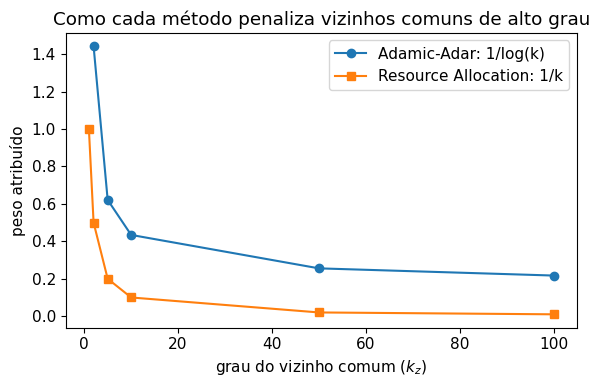

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(graus_exemplo, aa_pesos, marker='o', label='Adamic-Adar: 1/log(k)')
ax.plot(graus_exemplo, ra_pesos, marker='s', label='Resource Allocation: 1/k')
ax.set_xlabel('grau do vizinho comum ($k_z$)')
ax.set_ylabel('peso atribuído')
ax.set_title('Como cada método penaliza vizinhos comuns de alto grau')
ax.legend()
plt.tight_layout()
plt.show()

O gráfico deixa claro: para vizinhos comuns de grau baixo, os dois métodos atribuem pesos parecidos; mas conforme o grau aumenta, o Resource Allocation penaliza muito mais rapidamente do que o Adamic-Adar.

### Usando o NetworkX

In [ ]:
ra_resultados = list(nx.resource_allocation_index(G, pares_nao_conectados))

df_ra = pd.DataFrame(ra_resultados, columns=['u', 'v', 'resource_allocation'])
df_ra = df_ra.sort_values('resource_allocation', ascending=False).reset_index(drop=True)

df_ra.head(10)

,u,v,resource_allocation
0,0,8,0.583333
1,0,6,0.583333
2,2,5,0.533333
3,4,5,0.533333
4,2,3,0.533333
5,1,4,0.533333
6,1,6,0.333333
7,4,9,0.333333
8,2,7,0.333333
9,5,9,0.333333


### Reunindo os quatro métodos até agora

In [ ]:
df_quatro = (
    df_cn
    .merge(df_jaccard, on=['u', 'v'])
    .merge(df_aa, on=['u', 'v'])
    .merge(df_ra, on=['u', 'v'])
)

df_quatro.sort_values('common_neighbors', ascending=False).head(10)

,u,v,common_neighbors,jaccard,adamic_adar,resource_allocation
0,0,8,2,0.333333,1.631587,0.583333
2,4,5,2,0.400000,1.531574,0.533333
3,2,5,2,0.400000,1.531574,0.533333
4,2,3,2,0.500000,1.531574,0.533333
5,0,6,2,0.333333,1.631587,0.583333
1,1,4,2,0.500000,1.531574,0.533333
11,2,4,1,0.200000,0.621335,0.200000
16,3,8,1,0.200000,0.910239,0.333333
14,5,9,1,0.250000,0.910239,0.333333
13,2,7,1,0.250000,0.910239,0.333333


## 8. Preferential Attachment

Todos os métodos vistos até agora dependem, de alguma forma, dos **vizinhos em comum**. O Preferential Attachment segue uma lógica completamente diferente.

### A hipótese de ligação preferencial

> "Vértices que já possuem muitas conexões tendem a adquirir novas conexões com maior frequência."

Essa é a mesma ideia por trás do modelo de crescimento de redes de **Barabási-Albert** ("o rico fica mais rico"): hubs atraem mais conexões simplesmente por já serem hubs, não porque compartilham vizinhos com o novo vértice.

### A fórmula

$$
PA(i,j) = k_i \cdot k_j.
$$

Diferente de Common Neighbors, Jaccard, Adamic-Adar e Resource Allocation, o Preferential Attachment **não olha para a vizinhança em comum**, ele depende apenas dos graus dos dois vértices envolvidos.

### Cálculo manual

In [ ]:
for u, v in [(0, 9), (1, 7)]:
    pa = G.degree(u) * G.degree(v)
    print(f'PA({u}, {v}) = grau({u}) x grau({v}) = {G.degree(u)} x {G.degree(v)} = {pa}')

PA(0, 9) = grau(0) x grau(9) = 5 x 1 = 5
PA(1, 7) = grau(1) x grau(7) = 3 x 2 = 6


### Usando o NetworkX

In [ ]:
pa_resultados = list(nx.preferential_attachment(G, pares_nao_conectados))

df_pa = pd.DataFrame(pa_resultados, columns=['u', 'v', 'preferential_attachment'])
df_pa = df_pa.sort_values('preferential_attachment', ascending=False).reset_index(drop=True)

df_pa.head(10)

,u,v,preferential_attachment
0,0,8,15
1,0,6,15
2,1,5,12
3,4,5,12
4,3,5,12
5,2,5,12
6,0,7,10
7,1,6,9
8,1,8,9
9,4,6,9


### Um caso de discordância importante

Vamos procurar, entre os pares mais bem ranqueados pelo Preferential Attachment, algum que tenha **poucos ou nenhum** vizinho em comum.

In [ ]:
df_pa_vs_cn = df_pa.merge(df_cn, on=['u', 'v'])
df_pa_vs_cn.sort_values('preferential_attachment', ascending=False).head(8)

,u,v,preferential_attachment,common_neighbors
0,0,8,15,2
1,0,6,15,2
2,1,5,12,1
3,4,5,12,2
4,3,5,12,1
5,2,5,12,2
6,0,7,10,1
12,6,8,9,1


Repare que o par com maior `preferential_attachment`, envolvendo o vértice `0`, o hub do grafo, pode ter `common_neighbors` baixo ou até zero, dependendo do vértice com que ele é comparado. Isso acontece porque o Preferential Attachment **não exige nenhuma relação triádica**: ele simplesmente aposta que hubs continuarão acumulando conexões, independentemente de haver um caminho estrutural entre os dois vértices.

> **Pergunta conceitual:** em que tipo de rede você esperaria que Preferential Attachment funcionasse melhor — uma rede social de amizades, ou uma rede de citações onde artigos populares recebem cada vez mais citações? (Vamos investigar isso experimentalmente nas Seções 12-13.)

## 9. Comparação dos métodos

Vamos reunir todos os cinco índices calculados até aqui em uma única tabela, junto com os graus dos vértices envolvidos.

In [ ]:
df_todos = (
    df_cn
    .merge(df_jaccard, on=['u', 'v'])
    .merge(df_aa, on=['u', 'v'])
    .merge(df_ra, on=['u', 'v'])
    .merge(df_pa, on=['u', 'v'])
)

df_todos['grau_u'] = df_todos['u'].map(graus)
df_todos['grau_v'] = df_todos['v'].map(graus)

# Reordenando colunas
df_todos = df_todos[[
    'u', 'v', 'grau_u', 'grau_v',
    'common_neighbors', 'jaccard', 'adamic_adar',
    'resource_allocation', 'preferential_attachment'
]]

df_todos.head(10)

,u,v,grau_u,grau_v,common_neighbors,jaccard,adamic_adar,resource_allocation,preferential_attachment
0,0,8,5,3,2,0.333333,1.631587,0.583333,15
1,1,4,3,3,2,0.500000,1.531574,0.533333,9
2,4,5,3,4,2,0.400000,1.531574,0.533333,12
3,2,5,3,4,2,0.400000,1.531574,0.533333,12
4,2,3,3,3,2,0.500000,1.531574,0.533333,9
5,0,6,5,3,2,0.333333,1.631587,0.583333,15
6,1,5,3,4,1,0.166667,0.621335,0.200000,12
7,1,6,3,3,1,0.200000,0.910239,0.333333,9
8,7,8,2,3,1,0.250000,0.721348,0.250000,6
9,6,8,3,3,1,0.200000,0.721348,0.250000,9


### Top 10 por método

Vamos ver, lado a lado, quais pares cada método coloca no topo.

In [ ]:
medidas = ['common_neighbors', 'jaccard', 'adamic_adar', 'resource_allocation', 'preferential_attachment']

top10_por_metodo = {}
for medida in medidas:
    top = df_todos.sort_values(medida, ascending=False).head(10)
    top10_por_metodo[medida] = [f'({u},{v})' for u, v in zip(top['u'], top['v'])]

df_top10 = pd.DataFrame(top10_por_metodo)
df_top10.index = [f'#{i+1}' for i in range(10)]
df_top10

,common_neighbors,jaccard,adamic_adar,resource_allocation,preferential_attachment
#1,"(0,8)","(2,3)","(0,8)","(0,8)","(0,8)"
#2,"(4,5)","(1,4)","(0,6)","(0,6)","(0,6)"
#3,"(2,5)","(4,5)","(4,5)","(4,5)","(1,5)"
#4,"(2,3)","(2,5)","(2,5)","(2,5)","(3,5)"
#5,"(0,6)","(0,8)","(2,3)","(2,3)","(4,5)"
#6,"(1,4)","(0,6)","(1,4)","(1,4)","(2,5)"
#7,"(2,4)","(4,9)","(5,9)","(5,9)","(0,7)"
#8,"(3,8)","(5,9)","(3,8)","(3,8)","(2,3)"
#9,"(5,9)","(7,8)","(1,6)","(1,6)","(2,8)"
#10,"(2,7)","(2,7)","(4,9)","(4,9)","(1,8)"


### Quais pares aparecem em vários métodos?

Vamos contar, para cada par, em quantos "top 10" ele aparece.

In [ ]:
from collections import Counter

contagem = Counter()
for medida in medidas:
    top_pares = set(df_todos.sort_values(medida, ascending=False).head(10).apply(lambda row: (row['u'], row['v']), axis=1))
    for par in top_pares:
        contagem[par] += 1

df_contagem = pd.DataFrame(contagem.items(), columns=['par', 'n_metodos_top10'])
df_contagem = df_contagem.sort_values('n_metodos_top10', ascending=False).reset_index(drop=True)
df_contagem.head(10)

,par,n_metodos_top10
0,"(2.0, 5.0)",5
1,"(0.0, 6.0)",5
2,"(2.0, 3.0)",5
3,"(4.0, 5.0)",5
4,"(0.0, 8.0)",5
5,"(1.0, 4.0)",4
6,"(5.0, 9.0)",4
7,"(3.0, 8.0)",3
8,"(4.0, 9.0)",3
9,"(2.0, 7.0)",2


### Discussão

- **Pares que aparecem em vários métodos** costumam ser pares com vizinhos comuns de baixo grau *e* graus totais moderados. Eles são "recomendados" tanto pelos métodos baseados em vizinhança comum quanto, às vezes, coincidentemente, pelo Preferential Attachment.
- **Pares que mudam bastante de posição** entre métodos geralmente envolvem o vértice `0` (o hub): ele empurra o Preferential Attachment para cima, mas pode ser penalizado por Adamic-Adar e Resource Allocation quando aparece como vizinho comum.
- Cada índice privilegia uma propriedade estrutural diferente:
    - **Common Neighbors**: quantidade bruta de vizinhos compartilhados;
    - **Jaccard**: proporção de vizinhos compartilhados;
    - **Adamic-Adar / Resource Allocation**: qualidade dos vizinhos compartilhados (penalizando hubs);
    - **Preferential Attachment**: grau total dos vértices, sem exigir vizinhança comum.

> **Pergunta conceitual:** se você tivesse que escolher **um único método** para recomendar amizades em uma rede social, qual escolheria e por quê? E se a tarefa fosse prever quais artigos científicos populares receberão ainda mais citações?

## 10. Visualização das conexões mais prováveis

Vamos escolher o Adamic-Adar e visualizar as três conexões mais recomendadas por ele, sobrepostas ao grafo original.

In [ ]:
top3_aa = df_todos.sort_values('adamic_adar', ascending=False).head(3)
arestas_previstas_aa = list(zip(top3_aa['u'], top3_aa['v']))
print('Links previstos pelo Adamic-Adar:', arestas_previstas_aa)

Links previstos pelo Adamic-Adar: [(0, 8), (0, 6), (4, 5)]


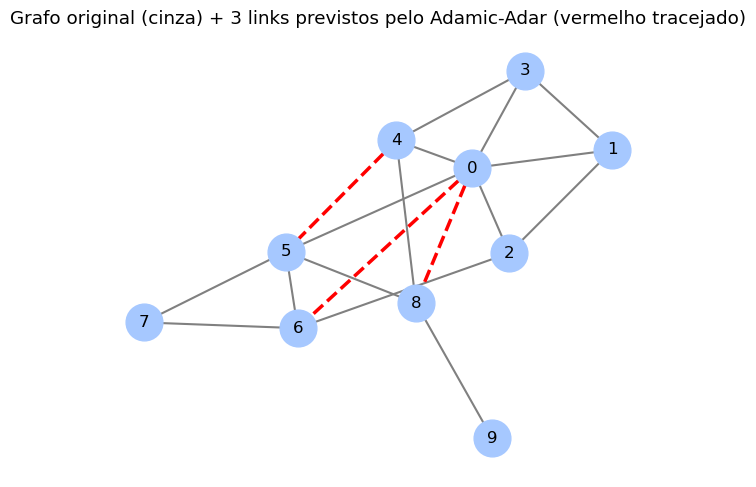

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))

nx.draw_networkx_nodes(G, pos, node_color='#a6c8ff', node_size=700, ax=ax)
nx.draw_networkx_edges(G, pos, width=1.5, ax=ax, edge_color='gray')
nx.draw_networkx_labels(G, pos, font_size=12, ax=ax)

# Arestas previstas: estilo visualmente distinto (tracejado, vermelho, mais grosso)
nx.draw_networkx_edges(
    G, pos, edgelist=arestas_previstas_aa,
    style='dashed', edge_color='red', width=2.5, ax=ax
)

ax.set_title('Grafo original (cinza) + 3 links previstos pelo Adamic-Adar (vermelho tracejado)')
ax.axis('off')
plt.tight_layout()
plt.show()

**Importante:** as arestas em vermelho tracejado **não fazem parte do grafo original**, são apenas recomendações produzidas pelo algoritmo. É essa a saída prática de um sistema de predição de links: uma lista de pares candidatos, ranqueados por escore.

### Comparando com Preferential Attachment

Links previstos pelo Preferential Attachment: [(0, 8), (0, 6), (1, 5)]


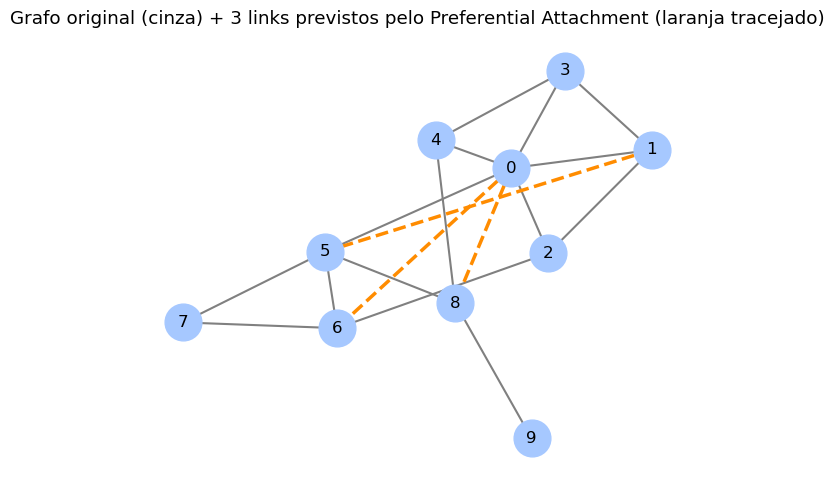

In [ ]:
top3_pa = df_todos.sort_values('preferential_attachment', ascending=False).head(3)
arestas_previstas_pa = list(zip(top3_pa['u'], top3_pa['v']))
print('Links previstos pelo Preferential Attachment:', arestas_previstas_pa)

fig, ax = plt.subplots(figsize=(6, 5))
nx.draw_networkx_nodes(G, pos, node_color='#a6c8ff', node_size=700, ax=ax)
nx.draw_networkx_edges(G, pos, width=1.5, ax=ax, edge_color='gray')
nx.draw_networkx_labels(G, pos, font_size=12, ax=ax)
nx.draw_networkx_edges(
    G, pos, edgelist=arestas_previstas_pa,
    style='dashed', edge_color='darkorange', width=2.5, ax=ax
)
ax.set_title('Grafo original (cinza) + 3 links previstos pelo Preferential Attachment (laranja tracejado)')
ax.axis('off')
plt.tight_layout()
plt.show()

Observe que as recomendações de Preferential Attachment tendem a envolver o vértice `0` (o hub) repetidamente, enquanto o Adamic-Adar tende a recomendar pares mais "localizados", que efetivamente compartilham vizinhos de baixo grau.

## 11. Experimento com uma aresta escondida

Até aqui, ranqueamos pares **sem nenhum vizinho em comum de referência** para saber se os métodos "acertam" ou não. Vamos agora introduzir uma primeira forma (ainda informal) de **avaliação**.

### A ideia

1. Escolhemos uma aresta que **sabemos que existe** no grafo original;
2. Removemos essa aresta temporariamente, criando uma versão "incompleta" do grafo;
3. Calculamos os índices de predição de links nessa versão incompleta;
4. Verificamos **em que posição do ranking** a aresta removida aparece.

Se o método for bom, a aresta removida deve aparecer bem posicionada no ranking, afinal, ela é uma conexão real que só não "vemos" mais.

In [ ]:
u_escondido, v_escondido = 2, 6  # aresta que sabemos existir em G

G_train = G.copy()
G_train.remove_edge(u_escondido, v_escondido)

print(f'G original: {G.number_of_edges()} arestas')
print(f'G_train (aresta ({u_escondido}, {v_escondido}) removida): {G_train.number_of_edges()} arestas')
print(f'G_train continua conexo? {nx.is_connected(G_train)}')

G original: 15 arestas
G_train (aresta (2, 6) removida): 14 arestas
G_train continua conexo? True


- `G` representa a rede completa (a "verdade");
- `G_train` representa aquilo que conseguimos observar;
- a aresta removida, `(2, 6)`, funciona como um link desconhecido que gostaríamos de recuperar.

Vamos calcular os cinco índices para todos os pares não conectados em `G_train` — e verificar a posição do par `(2, 6)` em cada ranking.

In [ ]:
def calcular_todos_indices(Grafo):
    '''Calcula os cinco índices de predição de links para todos os pares não conectados de Grafo.'''
    pares = list(nx.non_edges(Grafo))

    df = pd.DataFrame(pares, columns=['u', 'v'])
    df['common_neighbors'] = [common_neighbors_score(Grafo, u, v) for u, v in pares]

    jac = {(u, v): score for u, v, score in nx.jaccard_coefficient(Grafo, pares)}
    aa = {(u, v): score for u, v, score in nx.adamic_adar_index(Grafo, pares)}
    ra = {(u, v): score for u, v, score in nx.resource_allocation_index(Grafo, pares)}
    pa = {(u, v): score for u, v, score in nx.preferential_attachment(Grafo, pares)}

    df['jaccard'] = df.apply(lambda row: jac[(row['u'], row['v'])], axis=1)
    df['adamic_adar'] = df.apply(lambda row: aa[(row['u'], row['v'])], axis=1)
    df['resource_allocation'] = df.apply(lambda row: ra[(row['u'], row['v'])], axis=1)
    df['preferential_attachment'] = df.apply(lambda row: pa[(row['u'], row['v'])], axis=1)

    return df

df_train = calcular_todos_indices(G_train)
df_train.sort_values('adamic_adar', ascending=False).head(5)

,u,v,common_neighbors,jaccard,adamic_adar,resource_allocation,preferential_attachment
0,0,8,2,0.333333,1.631587,0.583333,15
23,4,5,2,0.400000,1.531574,0.533333,12
4,1,4,2,0.500000,1.531574,0.533333,9
10,2,3,2,0.666667,1.531574,0.533333,6
20,3,8,1,0.200000,0.910239,0.333333,9


In [ ]:
def posicao_no_ranking(df, medida, u, v):
    '''Retorna a posição (1 = melhor) do par (u, v) no ranking de uma medida.'''
    ordenado = df.sort_values(medida, ascending=False).reset_index(drop=True)
    mask = ((ordenado['u'] == u) & (ordenado['v'] == v)) | ((ordenado['u'] == v) & (ordenado['v'] == u))
    posicao = ordenado.index[mask][0] + 1
    return posicao, len(ordenado)

medidas = ['common_neighbors', 'jaccard', 'adamic_adar', 'resource_allocation', 'preferential_attachment']

resultados_posicao = []
for medida in medidas:
    posicao, total = posicao_no_ranking(df_train, medida, u_escondido, v_escondido)
    resultados_posicao.append({'metodo': medida, 'posicao_aresta_escondida': posicao, 'total_de_pares': total})

df_posicoes = pd.DataFrame(resultados_posicao)
df_posicoes

,metodo,posicao_aresta_escondida,total_de_pares
0,common_neighbors,26,31
1,jaccard,26,31
2,adamic_adar,26,31
3,resource_allocation,26,31
4,preferential_attachment,24,31


### Repetindo o experimento para outras arestas

Um único exemplo pode ser sorte (ou azar). Vamos repetir o processo escondendo algumas arestas diferentes e comparar o desempenho dos métodos.

In [ ]:
arestas_para_testar = [(2, 6), (4, 8), (0, 3), (5, 8)]

resultados_multiplos = []

for u_esc, v_esc in arestas_para_testar:
    G_temp = G.copy()
    G_temp.remove_edge(u_esc, v_esc)

    if not nx.is_connected(G_temp):
        print(f'Aviso: remover ({u_esc}, {v_esc}) desconecta a rede — pulando.')
        continue

    df_temp = calcular_todos_indices(G_temp)

    linha = {'aresta_escondida': f'({u_esc},{v_esc})'}
    for medida in medidas:
        posicao, total = posicao_no_ranking(df_temp, medida, u_esc, v_esc)
        linha[medida] = posicao
    resultados_multiplos.append(linha)

df_multiplos = pd.DataFrame(resultados_multiplos).set_index('aresta_escondida')
df_multiplos

,common_neighbors,jaccard,adamic_adar,resource_allocation,preferential_attachment
aresta_escondida,,,,,
"(2,6)",26,26,26,26,24
"(4,8)",18,18,18,18,25
"(0,3)",1,1,2,2,14
"(5,8)",19,19,19,19,22


### Discussão

Note que a posição da aresta escondida no ranking **varia bastante** de acordo com sua estrutura local:

- arestas que fazem parte de triângulos (ou seja, que têm vizinhos comuns) tendem a ser bem recuperadas por Common Neighbors, Jaccard, Adamic-Adar e Resource Allocation;
- arestas entre vértices de grau alto tendem a ser mais bem posicionadas por Preferential Attachment, independentemente de haver ou não vizinhos comuns.

Por enquanto, estamos usando apenas a **posição no ranking** como forma intuitiva de avaliação. Métricas mais formais — como ROC-AUC, Precision, Recall e Precision@k — ficam para as próximas aulas.

## 12. Experimento em uma rede maior

O exemplo didático foi útil para entender cada método em detalhe. Agora vamos repetir a ideia em uma rede real e clássica: o **Zachary's Karate Club**.

Essa rede registra as relações de amizade entre 34 membros de um clube de karatê universitário, observadas por Wayne Zachary na década de 1970. É um dos conjuntos de dados mais usados em ciência de redes, justamente por ser pequeno, real e bem documentado.

In [ ]:
G_karate = nx.karate_club_graph()

print(f'Número de nós: {G_karate.number_of_nodes()}')
print(f'Número de arestas: {G_karate.number_of_edges()}')

graus_karate = dict(G_karate.degree())
grau_medio_karate = np.mean(list(graus_karate.values()))
print(f'Grau médio: {grau_medio_karate:.2f}')

Número de nós: 34
Número de arestas: 78
Grau médio: 4.59


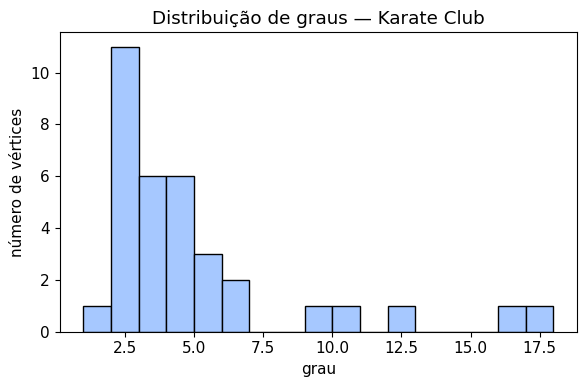

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(list(graus_karate.values()), bins=range(1, max(graus_karate.values()) + 2), edgecolor='black', color='#a6c8ff')
ax.set_xlabel('grau')
ax.set_ylabel('número de vértices')
ax.set_title('Distribuição de graus — Karate Club')
plt.tight_layout()
plt.show()

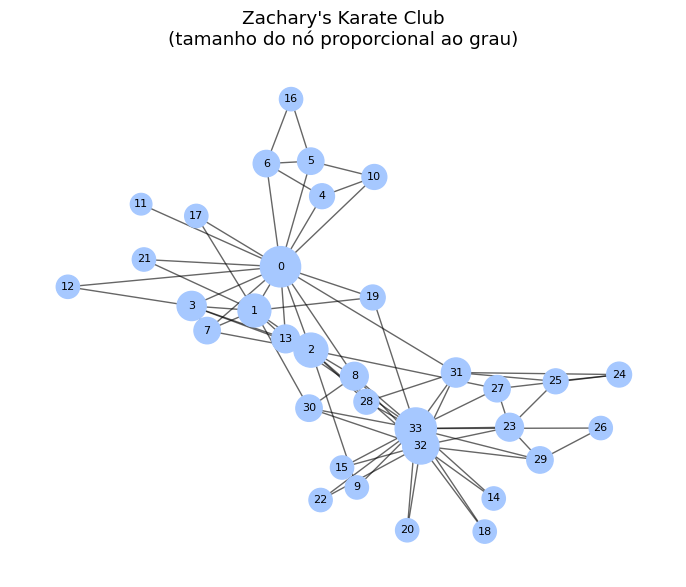

In [ ]:
pos_karate = nx.spring_layout(G_karate, seed=SEED)

fig, ax = plt.subplots(figsize=(7, 6))
tamanhos = [200 + 40 * graus_karate[n] for n in G_karate.nodes()]
nx.draw_networkx_nodes(G_karate, pos_karate, node_color='#a6c8ff', node_size=tamanhos, ax=ax)
nx.draw_networkx_edges(G_karate, pos_karate, width=1, alpha=0.6, ax=ax)
nx.draw_networkx_labels(G_karate, pos_karate, font_size=8, ax=ax)
ax.set_title("Zachary's Karate Club\n(tamanho do nó proporcional ao grau)")
ax.axis('off')
plt.tight_layout()
plt.show()

### Escondendo algumas arestas aleatoriamente

Vamos escolher aleatoriamente algumas arestas para remover, tomando cuidado para não desconectar a rede.

In [ ]:
rng = np.random.RandomState(SEED)

todas_arestas_karate = list(G_karate.edges())
rng.shuffle(todas_arestas_karate)

arestas_escondidas_karate = []
G_karate_train = G_karate.copy()

for u, v in todas_arestas_karate:
    if len(arestas_escondidas_karate) >= 8:
        break
    G_teste = G_karate_train.copy()
    G_teste.remove_edge(u, v)
    if nx.is_connected(G_teste):
        G_karate_train = G_teste
        arestas_escondidas_karate.append((u, v))

print(f'Arestas escondidas ({len(arestas_escondidas_karate)}):')
print(arestas_escondidas_karate)
print(f'G_karate_train continua conexo? {nx.is_connected(G_karate_train)}')
print(f'Arestas restantes: {G_karate_train.number_of_edges()} de {G_karate.number_of_edges()}')

Arestas escondidas (8):
[(3, 12), (0, 1), (3, 13), (0, 17), (32, 33), (2, 28), (0, 5), (15, 33)]
G_karate_train continua conexo? True
Arestas restantes: 70 de 78


### Calculando os índices e verificando o desempenho

Vamos calcular os cinco índices em `G_karate_train` e verificar, para cada aresta escondida, se ela aparece entre os **top 10** de cada método.

In [ ]:
df_karate_train = calcular_todos_indices(G_karate_train)

resultados_karate = []
for u_esc, v_esc in arestas_escondidas_karate:
    linha = {'aresta_escondida': f'({u_esc},{v_esc})'}
    for medida in medidas:
        posicao, total = posicao_no_ranking(df_karate_train, medida, u_esc, v_esc)
        linha[medida] = posicao
    resultados_karate.append(linha)

df_resultados_karate = pd.DataFrame(resultados_karate).set_index('aresta_escondida')
df_resultados_karate

,common_neighbors,jaccard,adamic_adar,resource_allocation,preferential_attachment
aresta_escondida,,,,,
"(3,12)",187,117,165,165,378
"(0,1)",2,50,2,2,6
"(3,13)",11,11,14,24,121
"(0,17)",324,352,315,315,147
"(32,33)",1,13,1,1,2
"(2,28)",256,317,443,443,102
"(0,5)",18,193,11,7,32
"(15,33)",267,269,254,254,134


In [ ]:
print('Quantas arestas escondidas ficaram entre os top 10 de cada método:')
for medida in medidas:
    acertos = (df_resultados_karate[medida] <= 10).sum()
    print(f'  {medida:26s}: {acertos} de {len(arestas_escondidas_karate)}')

Quantas arestas escondidas ficaram entre os top 10 de cada método:
  common_neighbors          : 2 de 8
  jaccard                   : 0 de 8
  adamic_adar               : 2 de 8
  resource_allocation       : 3 de 8
  preferential_attachment   : 2 de 8


Observe qual(is) método(s) consegue(m) posicionar melhor as arestas escondidas nessa rede real. Isso já antecipa uma discussão importante: **o desempenho relativo dos métodos depende da estrutura da rede**, não existe um método universalmente melhor.

## 13. Comparação com uma rede aleatória

Será que os métodos funcionariam igualmente bem em uma rede **sem** a estrutura de comunidades e triângulos típica de redes sociais? Vamos comparar o Karate Club com uma rede aleatória Erdős-Rényi de tamanho e densidade parecidos.

In [ ]:
n = G_karate.number_of_nodes()
m = G_karate.number_of_edges()
p = m / (n * (n - 1) / 2)  # probabilidade que gera, em média, o mesmo número de arestas

G_random = nx.erdos_renyi_graph(n=n, p=p, seed=SEED)

print(f'Karate Club:  {n} nós, {m} arestas, grau médio = {2*m/n:.2f}')
print(f'Erdos-Renyi:  {G_random.number_of_nodes()} nós, {G_random.number_of_edges()} arestas, '
      f'grau médio = {2*G_random.number_of_edges()/n:.2f}')
print(f'G_random é conexo? {nx.is_connected(G_random)}')

Karate Club:  34 nós, 78 arestas, grau médio = 4.59
Erdos-Renyi:  34 nós, 81 arestas, grau médio = 4.76
G_random é conexo? True


### Coeficiente de clustering

O coeficiente de clustering mede a proporção de triângulos "fechados" em relação a triângulos "possíveis" ao redor de cada vértice, que é exatamente a propriedade que os métodos baseados em vizinhos comuns exploram.

In [ ]:
clustering_karate = nx.average_clustering(G_karate)
clustering_random = nx.average_clustering(G_random)

print(f'Clustering médio — Karate Club:  {clustering_karate:.3f}')
print(f'Clustering médio — Erdos-Renyi:  {clustering_random:.3f}')

Clustering médio — Karate Club:  0.571
Clustering médio — Erdos-Renyi:  0.121


### Repetindo o experimento de arestas escondidas na rede aleatória

In [ ]:
todas_arestas_random = list(G_random.edges())
rng.shuffle(todas_arestas_random)

arestas_escondidas_random = []
G_random_train = G_random.copy()

for u, v in todas_arestas_random:
    if len(arestas_escondidas_random) >= 8:
        break
    G_teste = G_random_train.copy()
    G_teste.remove_edge(u, v)
    if nx.is_connected(G_teste):
        G_random_train = G_teste
        arestas_escondidas_random.append((u, v))

df_random_train = calcular_todos_indices(G_random_train)

resultados_random = []
for u_esc, v_esc in arestas_escondidas_random:
    linha = {'aresta_escondida': f'({u_esc},{v_esc})'}
    for medida in medidas:
        posicao, total = posicao_no_ranking(df_random_train, medida, u_esc, v_esc)
        linha[medida] = posicao
    resultados_random.append(linha)

df_resultados_random = pd.DataFrame(resultados_random).set_index('aresta_escondida')

print('Erdos-Renyi — quantas arestas escondidas ficaram entre os top 10:')
for medida in medidas:
    acertos = (df_resultados_random[medida] <= 10).sum() if len(df_resultados_random) else 0
    print(f'  {medida:26s}: {acertos} de {len(arestas_escondidas_random)}')

Erdos-Renyi — quantas arestas escondidas ficaram entre os top 10:
  common_neighbors          : 0 de 8
  jaccard                   : 0 de 8
  adamic_adar               : 0 de 8
  resource_allocation       : 0 de 8
  preferential_attachment   : 0 de 8


### Discussão

> **Por que métodos baseados em vizinhos comuns tendem a funcionar melhor em redes com fechamento triádico do que em grafos completamente aleatórios?**

A resposta está diretamente ligada ao coeficiente de clustering: em uma rede como o Karate Club, as conexões surgem em grande parte por fechamento triádico (amigos de amigos), o que produz muitos triângulos, e é exatamente essa estrutura que Common Neighbors, Jaccard, Adamic-Adar e Resource Allocation exploram. Já em uma rede Erdős-Rényi, as arestas são formadas de maneira totalmente aleatória e independente; não há motivo estrutural para que dois vértices com vizinhos em comum tenham maior chance de se conectar. Como resultado, o clustering médio da rede aleatória é muito mais baixo, e os métodos baseados em vizinhança comum perdem grande parte de seu poder preditivo.

## 14. Relação entre clustering e predição de links

Vamos considerar essa ideia de forma mais explícita. Muitos métodos clássicos de predição de links exploram diretamente a existência de **triângulos**.

Considere um caminho de comprimento 2:

$$
i - z - j.
$$

Se esse caminho "fecha", ele se transforma em um triângulo:

$$
i - z - j - i.
$$

O **novo link** ($i-j$) fecha o triângulo. Quanto mais caminhos de comprimento 2 existirem entre $i$ e $j$ (ou seja, quanto maior o `Common Neighbors`), mais "pressão estrutural" existe para que esse triângulo se feche, e é exatamente essa pressão que os índices baseados em vizinhança comum tentam capturar numericamente.

Vamos visualizar esse processo com um vértice do grafo didático.

In [ ]:
z = 6  # vizinho comum escolhido
i, j = 2, 7  # dois vizinhos de z, ainda não conectados entre si (verificando abaixo)

print(f'{i} e {j} são vizinhos de {z}?', i in G.neighbors(z), j in G.neighbors(z))
print(f'Existe aresta ({i}, {j})?', G.has_edge(i, j))

2 e 7 são vizinhos de 6? True True
Existe aresta (2, 7)? False


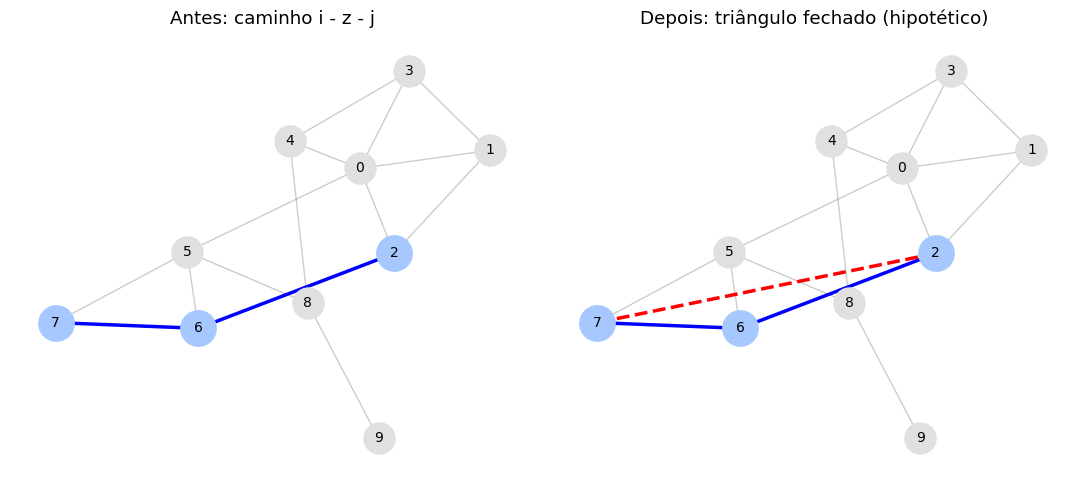

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, titulo, mostrar_fechamento in zip(axes, ['Antes: caminho i - z - j', 'Depois: triângulo fechado (hipotético)'], [False, True]):
    nx.draw_networkx_nodes(G, pos, node_color='#e0e0e0', node_size=500, ax=ax)
    nx.draw_networkx_edges(G, pos, width=1, alpha=0.4, ax=ax, edge_color='gray')
    nx.draw_networkx_labels(G, pos, font_size=10, ax=ax)

    # destaca i, z, j
    nx.draw_networkx_nodes(G, pos, nodelist=[i, z, j], node_color='#a6c8ff', node_size=650, ax=ax)
    nx.draw_networkx_edges(G, pos, edgelist=[(i, z), (z, j)], width=2.5, edge_color='blue', ax=ax)

    if mostrar_fechamento:
        nx.draw_networkx_edges(G, pos, edgelist=[(i, j)], width=2.5, style='dashed', edge_color='red', ax=ax)

    ax.set_title(titulo)
    ax.axis('off')

plt.tight_layout()
plt.show()

### Por que redes sociais favorecem métodos baseados em vizinhos comuns?

Redes sociais tendem a apresentar **fechamento triádico** de forma muito mais intensa do que outros tipos de rede, por razões sociais concretas: encontros em contextos compartilhados (trabalho, escola, eventos), apresentações através de amigos em comum, e a própria dinâmica de formação de grupos. Isso faz com que o coeficiente de clustering em redes sociais reais seja, tipicamente, muito mais alto do que o de uma rede aleatória de mesmo tamanho e densidade, exatamente o padrão que vimos na Seção 13.

## 15. Limitações dos métodos locais

Todos os métodos vistos neste notebook são chamados de **métodos locais**: eles usam apenas informação da vizinhança imediata (distância 1 ou 2) dos vértices envolvidos. Isso traz vantagens (simplicidade, velocidade, interpretabilidade) mas também limitações importantes:

1. **Pares distantes recebem escore zero.** Se dois vértices não têm nenhum vizinho em comum, Common Neighbors, Jaccard, Adamic-Adar e Resource Allocation atribuem escore 0 a esse par, mesmo que exista um caminho indireto relativamente curto (por exemplo, de comprimento 3) conectando-os.
2. **Os métodos utilizam apenas informação local.** Nenhum deles considera a posição global do vértice na rede (por exemplo, centralidade de intermediação) ou a estrutura de comunidades em larga escala.
3. **Redes muito esparsas podem possuir poucos triângulos.** Nesse cenário, a maioria dos pares terá `Common Neighbors = 0`, e os métodos baseados em vizinhança comum perdem quase todo o seu poder discriminativo.
4. **Preferential Attachment utiliza apenas os graus.** Ele ignora completamente a topologia local, dois vértices de alto grau em extremidades opostas da rede, sem nenhuma relação estrutural, ainda recebem escore alto.
5. **Nenhuma das medidas utiliza atributos dos vértices.** Informações como idade, localização, interesses ou categoria de um item nunca entram no cálculo, apenas a topologia da rede.
6. **A estrutura da rede pode mudar ao longo do tempo.** Os métodos aqui tratam o grafo como estático; em redes dinâmicas, a mesma aresta pode ser altamente provável hoje e improvável daqui a um ano.
7. **Métodos diferentes podem funcionar melhor em tipos diferentes de rede**, como vimos nas Seções 12-13, não existe um vencedor único e universal.

### O que vem a seguir (fora do escopo deste notebook)

Esses métodos locais são apenas o ponto de partida da área. Conceitualmente, os próximos passos incluem:

- **métodos baseados em caminhos** (não apenas vizinhos diretos, mas caminhos de comprimento maior);
- **Katz Index** (soma ponderada de todos os caminhos entre dois vértices, com pesos decrescentes por comprimento);
- **caminhadas aleatórias** (*random walks*), como *Random Walk with Restart*;
- **embeddings de grafos** (representações vetoriais aprendidas dos vértices, como node2vec e DeepWalk);
- **aprendizado de máquina** (tratando a predição de links como um problema de classificação supervisionada);
- **Graph Neural Networks (GNNs)**, que aprendem diretamente representações a partir da estrutura e de eventuais atributos.

Não vamos implementar nenhum desses métodos aqui, a ideia é apenas situar os métodos locais dentro de um panorama maior.

## 16. Conclusões

Neste notebook, exploramos os fundamentos da predição de links a partir de **medidas estruturais clássicas**, todas baseadas apenas na topologia do grafo:

| Método | Ideia principal | Usa vizinhos comuns? | Penaliza hubs? |
|---|---|---|---|
| Common Neighbors | número de vizinhos compartilhados | Sim | Não |
| Jaccard | proporção de vizinhos compartilhados | Sim | Indiretamente |
| Adamic-Adar | vizinhos comuns raros são mais importantes | Sim | Sim |
| Resource Allocation | distribuição de recursos pelos vizinhos | Sim | Sim (mais forte) |
| Preferential Attachment | vértices de alto grau tendem a se conectar | Não | Não |

A progressão conceitual que percorremos foi:

$$
\text{estrutura local} \;\rightarrow\; \text{similaridade} \;\rightarrow\; \text{ranking de pares} \;\rightarrow\; \text{predição de links}.
$$

Começamos com a intuição de fechamento triádico e homofilia (Seção 2), construímos um grafo didático controlado (Seção 3), formalizamos cinco medidas clássicas (Seções 4-8), comparamos seus rankings (Seção 9) e visualizamos suas recomendações (Seção 10). Em seguida, introduzimos uma primeira forma de avaliação — esconder uma aresta conhecida e verificar sua posição no ranking (Seção 11) — e testamos tudo isso em uma rede real (Zachary's Karate Club) e em uma rede aleatória de controle (Seções 12-13), relacionando os resultados ao coeficiente de clustering (Seção 14). Por fim, discutimos as limitações inerentes a métodos puramente locais (Seção 15).

## Exercícios

Crie um novo notebook com as soluções, que deverão ser entregues no Moodle.

1 - Construa manualmente (com `nx.Graph()` e `add_edges_from`) um novo grafo com 10 vértices, diferente do grafo `G` usado no notebook. Encontre os cinco pares não conectados com maior número de vizinhos comuns.

2 - Compare Common Neighbors e Jaccard no grafo `G` (ou no seu grafo do Exercício 1) e identifique um par de vértices cuja posição no ranking seja muito diferente nos dois métodos. Explique, em texto, o motivo dessa diferença.

3 - Encontre, no grafo `G`, dois pares com o mesmo `Common Neighbors` mas valores diferentes de `Adamic-Adar`. Explique a diferença observada em termos do grau dos vizinhos comuns.

4 - Remova uma aresta da rede Karate Club (diferente das usadas na Seção 12) e verifique se ela aparece entre os 10 primeiros pares sugeridos por cada um dos cinco métodos.

5 - Escolha uma rede social no site: https://icon.colorado.edu. Remova 10% das arestas da rede e depois faça a predição usando os métodos que usamos nesse notebook, isto é, identique as 10% arestas com maiores valores dos coeficientes. Calcule a porcentagem de verdadeiros positivos e falsos positivos para cada método.

6 - Implemente mais algumas medidas descritas no artigo: A Survey of Link Prediction in Complex Networks (ACM, 2016). Compare com as que estudamos nesse notebook. (exercício livre, seja criativ@).